# Can NLI Models Handle Negation?
## A Cross-Lingual Study of English and German

This notebook evaluates two multilingual Natural Language Inference (NLI) models on a controlled, balanced subset of XNLI. The experiment focuses on explicit negation in English and German.

**Research Questions**
- **RQ1:** How does negation affect NLI performance?
- **RQ2:** Does negation robustness differ between English and German?
- **RQ3:** Which types of negation are most challenging for NLI models?


## 1. Dataset

We use the English and German test sets of XNLI.

In [ ]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score

# Load English and German XNLI test sets
en = load_dataset("facebook/xnli", "en")
de = load_dataset("facebook/xnli", "de")

en_test = en["test"].to_pandas()
de_test = de["test"].to_pandas()

en_test["language"] = "English"
de_test["language"] = "German"

test_df = pd.concat(
    [en_test, de_test],
    ignore_index=True
)

print("Total examples:", len(test_df))
print("English examples:", len(en_test))
print("German examples:", len(de_test))
print("Columns:", list(test_df.columns))


README.md:   0%|          | 0.00/20.8k [00:00<?, ?B/s]

en/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 50.2MB            

en/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

en/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  308kB            

en/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

de/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/392702 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5010 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2490 [00:00<?, ? examples/s]

Total examples: 10020
English examples: 5010
German examples: 5010
Columns: ['premise', 'hypothesis', 'label', 'language']


## 2. Negation Detection

We define **explicit lexical negation** separately for English and German. An example is marked as negated when at least one listed negation marker occurs in the premise or hypothesis.

In [ ]:
english_negations = {
    "not", "no", "never", "nobody", "nothing",
    "neither", "nowhere", "n't"
}

german_negations = {
    "nicht", "kein", "keine", "keinen", "keinem",
    "keiner", "keines", "nie", "niemand", "nichts",
    "weder", "nirgendwo"
}


In [ ]:
def detect_negation(row):
    text = (
        str(row["premise"]) + " " +
        str(row["hypothesis"])
    ).lower()

    words = set(
        re.findall(r"\b[\wäöüß]+\b", text)
    )

    if row["language"] == "English":
        return bool(words & english_negations)

    if row["language"] == "German":
        return bool(words & german_negations)

    return False


test_df["has_negation"] = test_df.apply(
    detect_negation,
    axis=1
)

print(
    test_df.groupby(
        ["language", "has_negation"]
    ).size()
)


language  has_negation
English   False           3751
          True            1259
German    False           3322
          True            1688
dtype: int64


## 3. XNLI Labels and Balanced Evaluation Set

XNLI uses three labels. We map the integer labels to their semantic categories and then construct a balanced evaluation set.

For every combination of **language × negation status × NLI label**, 50 examples are sampled. This produces **600 examples** in total.

Due to computational constraints, we evaluated 600 examples sampled from the 10,020 English and German test examples.

In [ ]:
label_mapping = {
    0: "entailment",
    1: "neutral",
    2: "contradiction"
}

test_df["gold_label"] = test_df["label"].map(label_mapping)

balanced_parts = []

for language in ["English", "German"]:
    for negated in [False, True]:
        for label in ["contradiction", "entailment", "neutral"]:

            subset = test_df[
                (test_df["language"] == language) &
                (test_df["has_negation"] == negated) &
                (test_df["gold_label"] == label)
            ]

            sample = subset.sample(
                n=50,
                random_state=42
            )

            balanced_parts.append(sample)

experiment_df = (
    pd.concat(balanced_parts)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print("Total evaluation examples:", len(experiment_df))

balance_check = (
    experiment_df
    .groupby(["language", "has_negation", "gold_label"])
    .size()
)

print("\nBalance check:")
print(balance_check)


Total evaluation examples: 600

Balance check:
language  has_negation  gold_label   
English   False         contradiction    50
                        entailment       50
                        neutral          50
          True          contradiction    50
                        entailment       50
                        neutral          50
German    False         contradiction    50
                        entailment       50
                        neutral          50
          True          contradiction    50
                        entailment       50
                        neutral          50
dtype: int64


## 4. NLI Models and Inference Setup

We evaluate two multilingual NLI models:

- **XLM-RoBERTa**
- **mDeBERTa**

GPU acceleration is used when available.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

MODEL_NAMES = {
    "XLM-RoBERTa": "joeddav/xlm-roberta-large-xnli",
    "mDeBERTa": "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"
}

print("Device:", device)


Device: cuda


### Load NLI Models

In [ ]:
models = {}

for model_name, model_id in MODEL_NAMES.items():

    tokenizer = AutoTokenizer.from_pretrained(model_id)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_id
    ).to(device)

    model.eval()

    models[model_name] = {
        "tokenizer": tokenizer,
        "model": model
    }

    print(f"Loaded: {model_name}")


config.json:   0%|          | 0.00/734 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.24GB            

...

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  558MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Loaded: mDeBERTa


## 5. Batch NLI Inference

Premise–hypothesis pairs are processed in batches. For each example we store the predicted NLI label and prediction confidence.

In [ ]:
def predict_batch(
    model_info,
    premises,
    hypotheses,
    batch_size=16
):
    tokenizer = model_info["tokenizer"]
    model = model_info["model"]

    predictions = []
    confidences = []

    for start in range(0, len(premises), batch_size):

        batch_premises = premises[start:start + batch_size]
        batch_hypotheses = hypotheses[start:start + batch_size]

        encoded = tokenizer(
            batch_premises,
            batch_hypotheses,
            padding=True,
            truncation=True,
            return_tensors="pt"
        )

        encoded = {
            key: value.to(device)
            for key, value in encoded.items()
        }

        with torch.no_grad():
            outputs = model(**encoded)

        probabilities = torch.softmax(
            outputs.logits,
            dim=-1
        )

        batch_predictions = torch.argmax(
            probabilities,
            dim=-1
        )

        batch_confidences = torch.max(
            probabilities,
            dim=-1
        ).values

        predictions.extend(
            batch_predictions.cpu().numpy()
        )

        confidences.extend(
            batch_confidences.cpu().numpy()
        )

    # Convert model label IDs to semantic labels.
    id2label = model.config.id2label

    predictions = [
        id2label[int(pred)].lower()
        for pred in predictions
    ]

    return predictions, confidences


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

CUDA available: True
GPU: Tesla T4


In [ ]:
balanced_results = experiment_df.copy()

for model_name, model_info in models.items():

    print(f"Running {model_name}...")

    predictions, confidences = predict_batch(
        model_info,
        balanced_results["premise"].tolist(),
        balanced_results["hypothesis"].tolist(),
        batch_size=32
    )

    balanced_results[f"{model_name}_prediction"] = predictions
    balanced_results[f"{model_name}_confidence"] = confidences

    print(f"{model_name} completed.")

print("Inference completed.")

Running XLM-RoBERTa...
XLM-RoBERTa completed.
Running mDeBERTa...
mDeBERTa completed.
Inference completed.


## 6. Model Inference on the Balanced Dataset

In [ ]:
balanced_results = experiment_df.copy()

for model_name, model_info in models.items():

    predictions, confidences = predict_batch(
        model_info,
        balanced_results["premise"].tolist(),
        balanced_results["hypothesis"].tolist(),
        batch_size=16
    )

    balanced_results[f"{model_name}_prediction"] = predictions
    balanced_results[f"{model_name}_confidence"] = confidences

print("Inference completed.")


Inference completed.


## 7. Overall Performance

We report Accuracy and Macro-F1 on the complete balanced evaluation set.

In [ ]:
overall_results = []

for model_name in MODEL_NAMES:

    pred_col = f"{model_name}_prediction"

    accuracy = accuracy_score(
        balanced_results["gold_label"],
        balanced_results[pred_col]
    )

    macro_f1 = f1_score(
        balanced_results["gold_label"],
        balanced_results[pred_col],
        average="macro"
    )

    overall_results.append({
        "Model": model_name,
        "Accuracy": accuracy * 100,
        "Macro F1": macro_f1 * 100
    })

overall_df = pd.DataFrame(overall_results)

display(overall_df.round(2))


,Model,Accuracy,Macro F1
0,XLM-RoBERTa,100.00,100.00
1,mDeBERTa,84.83,84.85


## 8. RQ1: Effect of Negation

We compare performance on negated and non-negated examples for each model.

Our model is joeddav/xlm-roberta-large-xnli, while our evaluation data comes from XNLI. So we are evaluating a model specifically trained/fine-tuned for this benchmark. Very high performance is therefore possible.


In [ ]:
rq1_results = []

for model_name in MODEL_NAMES:

    pred_col = f"{model_name}_prediction"

    for negated in [False, True]:

        subset = balanced_results[
            balanced_results["has_negation"] == negated
        ]

        accuracy = accuracy_score(
            subset["gold_label"],
            subset[pred_col]
        )

        macro_f1 = f1_score(
            subset["gold_label"],
            subset[pred_col],
            average="macro"
        )

        rq1_results.append({
            "Model": model_name,
            "Negation": "Negated" if negated else "Non-negated",
            "N": len(subset),
            "Accuracy": accuracy * 100,
            "Macro F1": macro_f1 * 100
        })

rq1_df = pd.DataFrame(rq1_results)

display(rq1_df.round(2))


,Model,Negation,N,Accuracy,Macro F1
0,XLM-RoBERTa,Non-negated,300,100.00,100.00
1,XLM-RoBERTa,Negated,300,100.00,100.00
2,mDeBERTa,Non-negated,300,84.33,84.30
3,mDeBERTa,Negated,300,85.33,85.29


## 9. RQ2: Cross-Lingual Performance

We compare English and German performance for each model.

In [ ]:
rq2_results = []

for model_name in MODEL_NAMES:

    pred_col = f"{model_name}_prediction"

    for language in ["English", "German"]:

        subset = balanced_results[
            balanced_results["language"] == language
        ]

        accuracy = accuracy_score(
            subset["gold_label"],
            subset[pred_col]
        )

        macro_f1 = f1_score(
            subset["gold_label"],
            subset[pred_col],
            average="macro"
        )

        rq2_results.append({
            "Model": model_name,
            "Language": language,
            "N": len(subset),
            "Accuracy": accuracy * 100,
            "Macro F1": macro_f1 * 100
        })

rq2_df = pd.DataFrame(rq2_results)

display(rq2_df.round(2))


,Model,Language,N,Accuracy,Macro F1
0,XLM-RoBERTa,English,300,100.00,100.00
1,XLM-RoBERTa,German,300,100.00,100.00
2,mDeBERTa,English,300,89.33,89.35
3,mDeBERTa,German,300,80.33,80.33


## 10. Language × Negation Analysis

We examine the interaction between language and negation by evaluating English/German and negated/non-negated conditions separately.

In [ ]:
detailed_results = []

for model_name in MODEL_NAMES:

    pred_col = f"{model_name}_prediction"

    for language in ["English", "German"]:
        for negated in [False, True]:

            subset = balanced_results[
                (balanced_results["language"] == language) &
                (balanced_results["has_negation"] == negated)
            ]

            accuracy = accuracy_score(
                subset["gold_label"],
                subset[pred_col]
            )

            macro_f1 = f1_score(
                subset["gold_label"],
                subset[pred_col],
                average="macro"
            )

            detailed_results.append({
                "Model": model_name,
                "Language": language,
                "Negated": negated,
                "Negation": "Negated" if negated else "Non-negated",
                "N": len(subset),
                "Accuracy": accuracy * 100,
                "Macro F1": macro_f1 * 100
            })

detailed_df = pd.DataFrame(detailed_results)

display(detailed_df.round(2))


,Model,Language,Negated,Negation,N,Accuracy,Macro F1
0,XLM-RoBERTa,English,False,Non-negated,150,100.00,100.00
1,XLM-RoBERTa,English,True,Negated,150,100.00,100.00
2,XLM-RoBERTa,German,False,Non-negated,150,100.00,100.00
3,XLM-RoBERTa,German,True,Negated,150,100.00,100.00
4,mDeBERTa,English,False,Non-negated,150,88.00,88.06
5,mDeBERTa,English,True,Negated,150,90.67,90.63
6,mDeBERTa,German,False,Non-negated,150,80.67,80.45
7,mDeBERTa,German,True,Negated,150,80.00,79.93


## 11. RQ3: Negation Types

Explicit negation markers are grouped into language-specific lexical categories. Because some categories are small, category-level results with very low sample sizes should be interpreted cautiously.

In [ ]:
def get_negation_type(row):

    text = (
        str(row["premise"]) + " " +
        str(row["hypothesis"])
    ).lower()

    words = re.findall(
        r"\b[\wäöüß]+\b",
        text
    )

    if row["language"] == "English":

        if "not" in words or "n't" in words:
            return "not"
        elif "no" in words:
            return "no"
        elif "never" in words:
            return "never"
        elif "nothing" in words:
            return "nothing"
        elif "nobody" in words:
            return "nobody"
        elif "neither" in words:
            return "neither"
        elif "nowhere" in words:
            return "nowhere"

    elif row["language"] == "German":

        if "nicht" in words:
            return "nicht"
        elif any(
            w in words
            for w in [
                "kein", "keine", "keinen",
                "keinem", "keiner", "keines"
            ]
        ):
            return "kein"
        elif "nie" in words:
            return "nie"
        elif "nichts" in words:
            return "nichts"
        elif "niemand" in words:
            return "niemand"
        elif "weder" in words:
            return "weder"
        elif "nirgendwo" in words:
            return "nirgendwo"

    return "none"


balanced_results["negation_type"] = balanced_results.apply(
    get_negation_type,
    axis=1
)


In [ ]:
category_results = []

for model_name in MODEL_NAMES:

    pred_col = f"{model_name}_prediction"

    for language in ["English", "German"]:

        subset_language = balanced_results[
            balanced_results["language"] == language
        ]

        for negation_type in sorted(
            subset_language["negation_type"].unique()
        ):

            if negation_type == "none":
                continue

            subset = subset_language[
                subset_language["negation_type"] == negation_type
            ]

            accuracy = accuracy_score(
                subset["gold_label"],
                subset[pred_col]
            )

            macro_f1 = f1_score(
                subset["gold_label"],
                subset[pred_col],
                average="macro"
            )

            category_results.append({
                "Model": model_name,
                "Language": language,
                "Negation Type": negation_type,
                "N": len(subset),
                "Accuracy": accuracy * 100,
                "Macro F1": macro_f1 * 100
            })

category_df = pd.DataFrame(category_results)

display(
    category_df
    .sort_values(["Language", "Negation Type", "Model"])
    .round(2)
)


,Model,Language,Negation Type,N,Accuracy,Macro F1
0,XLM-RoBERTa,English,neither,1,100.00,100.00
11,mDeBERTa,English,neither,1,0.00,0.00
1,XLM-RoBERTa,English,never,13,100.00,100.00
12,mDeBERTa,English,never,13,92.31,85.19
2,XLM-RoBERTa,English,no,27,100.00,100.00
13,mDeBERTa,English,no,27,96.30,96.89
3,XLM-RoBERTa,English,not,102,100.00,100.00
14,mDeBERTa,English,not,102,89.22,89.24
4,XLM-RoBERTa,English,nothing,7,100.00,100.00
15,mDeBERTa,English,nothing,7,100.00,100.00


## 12. Figure 1 — Accuracy by Language and Negation - Hypothesis 1

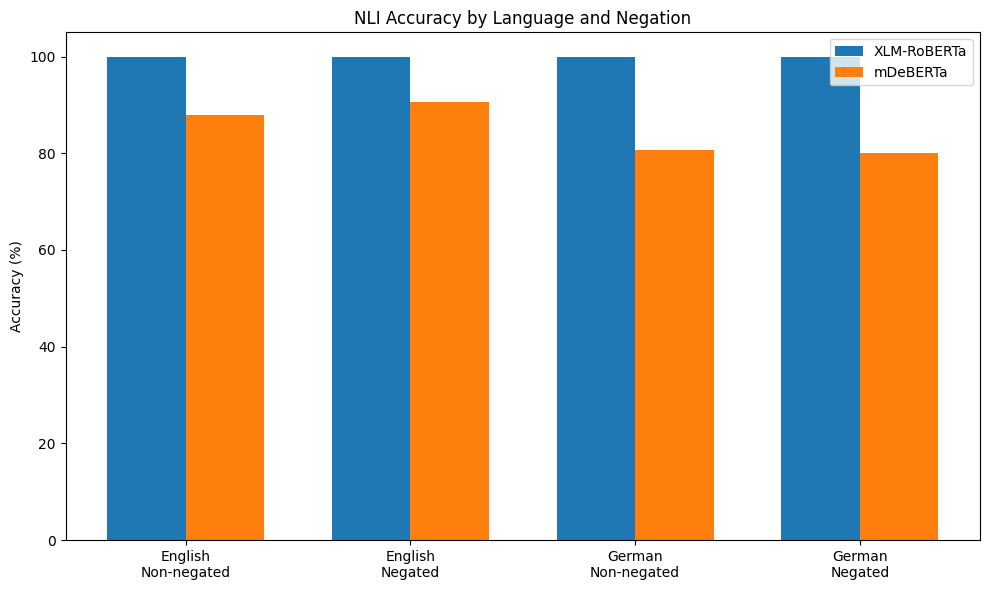

In [ ]:
plot_df = detailed_df.copy()

conditions = [
    ("English", False, "English\nNon-negated"),
    ("English", True, "English\nNegated"),
    ("German", False, "German\nNon-negated"),
    ("German", True, "German\nNegated")
]

x = np.arange(len(conditions))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

for i, model_name in enumerate(MODEL_NAMES):

    values = []

    for language, negated, _ in conditions:

        row = plot_df[
            (plot_df["Model"] == model_name) &
            (plot_df["Language"] == language) &
            (plot_df["Negated"] == negated)
        ]

        values.append(row["Accuracy"].iloc[0])

    ax.bar(
        x + (i - 0.5) * width,
        values,
        width,
        label=model_name
    )

ax.set_xticks(x)
ax.set_xticklabels([c[2] for c in conditions])
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 105)
ax.set_title("NLI Accuracy by Language and Negation")
ax.legend()

plt.tight_layout()
plt.show()


## 14. Figure 2 — Change in Accuracy between English and German - Hypothesis 2

Positive values indicate higher accuracy on negated examples; negative values indicate lower accuracy on negated examples.

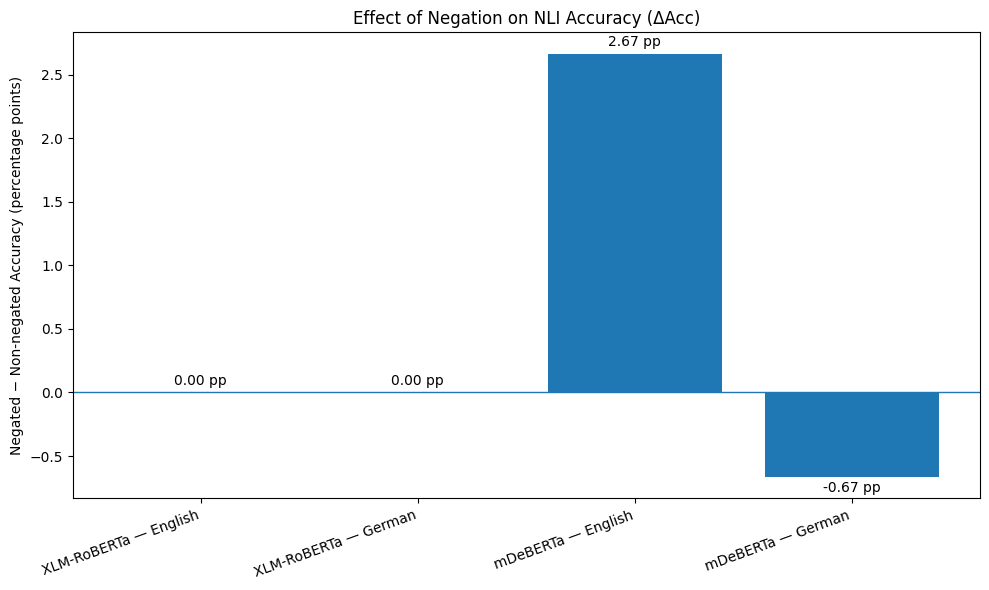

Negated,Model,Language,Negation Effect (pp)
0,XLM-RoBERTa,English,0.00
1,XLM-RoBERTa,German,0.00
2,mDeBERTa,English,2.67
3,mDeBERTa,German,-0.67


In [ ]:
effect_df = detailed_df.pivot_table(
    index=["Model", "Language"],
    columns="Negated",
    values="Accuracy"
).reset_index()

# ΔAcc = Negated accuracy − Non-negated accuracy
effect_df["Negation Effect (pp)"] = (
    effect_df[True] - effect_df[False]
)

effect_df["Condition"] = (
    effect_df["Model"] + " — " + effect_df["Language"]
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    effect_df["Condition"],
    effect_df["Negation Effect (pp)"]
)

# Add values above bars
ax.bar_label(
    bars,
    labels=[
        f"{v:.2f} pp"
        for v in effect_df["Negation Effect (pp)"]
    ],
    padding=3
)

ax.axhline(0, linewidth=1)

ax.set_ylabel(
    "Negated − Non-negated Accuracy (percentage points)"
)
ax.set_title("Effect of Negation on NLI Accuracy (ΔAcc)")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

display(
    effect_df[
        ["Model", "Language", "Negation Effect (pp)"]
    ].round(2)
)

## 13. Figure 3 — Performance by Negation Type - Hypothesis 3

For readability, the plot focuses on categories with at least 9 examples.

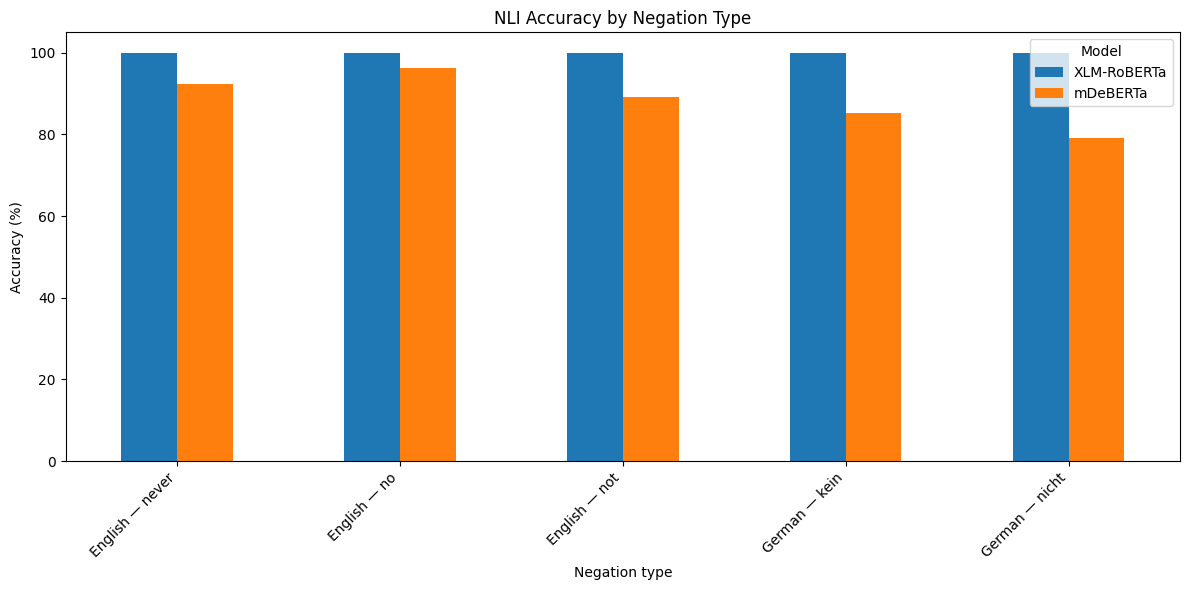

In [ ]:
plot_categories = category_df[
    category_df["N"] >= 9
].copy()

plot_categories["Condition"] = (
    plot_categories["Language"] +
    " — " +
    plot_categories["Negation Type"]
)

pivot = plot_categories.pivot_table(
    index="Condition",
    columns="Model",
    values="Accuracy"
)

ax = pivot.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_ylabel("Accuracy (%)")
ax.set_xlabel("Negation type")
ax.set_ylim(0, 105)
ax.set_title("NLI Accuracy by Negation Type")
ax.legend(title="Model")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 15. Limitations

- Negation is detected using explicit lexical markers and may miss implicit or syntactic negation.
- The experiment uses a balanced subset of 600 XNLI test examples rather than the complete test set.
- Some negation-type categories contain relatively few examples, limiting the strength of category-level conclusions.
- Dataset overlap: XNLI-fine-tuned models may have seen parts of the evaluation data during training, limiting the validity of XNLI as an unseen test set.
